<a href="https://colab.research.google.com/github/SilvanaBContreras/AA_TP1_G8/blob/main/AA_TP1_regresion_log.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV


In [3]:
URL_BASE = 'https://github.com/SilvanaBContreras/AA_TP1_G8/raw/refs/heads/main/'

archivos_a_cargar = {
    'X_train_completo.parquet': 'X_train',
    'y_train.parquet': 'y_train',
    'X_test_completo.parquet': 'X_test',
    'y_test.parquet': 'y_test',
    'X_train_reducido.parquet': 'X_train_short',
    'X_test_reducido.parquet': 'X_test_short',
    'X_transf.parquet': 'X_transf',
    'y.parquet': 'y',
    'y_ternaria.parquet': 'y_ternaria',
    'y_ternaria.parquet': 'y_ternaria',
    'X_train_ternaria.parquet': 'X_train_ternaria',
    'X_test_ternaria.parquet': 'X_test_ternaria',
    'y_train_ternaria.parquet': 'y_train_ternaria',
    'y_test_ternaria.parquet': 'y_test_ternaria'
}

def cargar_conjunto(nombre_archivo):
    """Carga un archivo Parquet desde la URL de GitHub."""
    full_url = URL_BASE + nombre_archivo
    data = pd.read_parquet(full_url)

    # Si es un DataFrame con una sola columna (que era originalmente una Series 'y'),
    # la convertimos de vuelta a Series con .squeeze()
    if data.shape[1] == 1:
        return data.squeeze()

    return data

# Crear un diccionario para almacenar todas las variables cargadas
variables_cargadas = {}

# Cargar y asignar dinámicamente
for nombre_archivo, nombre_variable in archivos_a_cargar.items():
    datos = cargar_conjunto(nombre_archivo)
    variables_cargadas[nombre_variable] = datos
    print(f" Cargado {nombre_archivo} como la variable '{nombre_variable}'")

# Asignar las variables al espacio de nombres de la notebook
X_train = variables_cargadas['X_train']
y_train = variables_cargadas['y_train']
X_test = variables_cargadas['X_test']
y_test = variables_cargadas['y_test']
X_train_short = variables_cargadas['X_train_short']
X_test_short = variables_cargadas['X_test_short']
X_transf = variables_cargadas['X_transf']
y = variables_cargadas['y']
y_ternaria = variables_cargadas['y_ternaria']
X_train_ternaria = variables_cargadas['X_train_ternaria']
X_test_ternaria = variables_cargadas['X_test_ternaria']
y_train_ternaria = variables_cargadas['y_train_ternaria']
y_test_ternaria = variables_cargadas['y_test_ternaria']


print("\n--- Verificación Final ---")
print(f"Variable X_train cargada. Dimensiones: {X_train.shape}")
print(f"Variable X_train_short cargada. Dimensiones: {X_train_short.shape}")
print("¡Estás lista para comenzar a entrenar y comparar modelos! ")

 Cargado X_train_completo.parquet como la variable 'X_train'
 Cargado y_train.parquet como la variable 'y_train'
 Cargado X_test_completo.parquet como la variable 'X_test'
 Cargado y_test.parquet como la variable 'y_test'
 Cargado X_train_reducido.parquet como la variable 'X_train_short'
 Cargado X_test_reducido.parquet como la variable 'X_test_short'
 Cargado X_transf.parquet como la variable 'X_transf'
 Cargado y.parquet como la variable 'y'
 Cargado y_ternaria.parquet como la variable 'y_ternaria'
 Cargado X_train_ternaria.parquet como la variable 'X_train_ternaria'
 Cargado X_test_ternaria.parquet como la variable 'X_test_ternaria'
 Cargado y_train_ternaria.parquet como la variable 'y_train_ternaria'
 Cargado y_test_ternaria.parquet como la variable 'y_test_ternaria'

--- Verificación Final ---
Variable X_train cargada. Dimensiones: (40257, 51)
Variable X_train_short cargada. Dimensiones: (40257, 49)
¡Estás lista para comenzar a entrenar y comparar modelos! 


In [2]:
X_train =pd.read_parquet("data/X_train_completo.parquet")
X_test= pd.read_parquet("data/X_test_completo.parquet")
y_train=pd.read_parquet("data/y_train.parquet")
y_test=pd.read_parquet("data/y_test.parquet")

print(X_train.shape , X_test.shape , y_train.shape , y_test.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'data/X_train_completo.parquet'

In [ ]:
y_train["target_binaria"].value_counts()

target_binaria
1    24979
0    15278
Name: count, dtype: int64

In [ ]:
hiperparametros = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': [None, 'balanced']
}

optimizacion  = RandomizedSearchCV(LogisticRegression(max_iter=1000) ,
                                    hiperparametros,
                                    cv=5,
                                    n_iter=20,
                                    scoring="f1",
                                    random_state=42,
                                    n_jobs=8)
optimizacion.fit(X_train , y_train)

c:\Users\chris\Data_science\Ms Data Mining UBA\2do_Cuatrimestre\AA\TPs\student-retention-ml\env_ml\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,estimator,LogisticRegre...max_iter=1000)
,param_distributions,"{'C': [0.001, 0.01, ...], 'class_weight': [None, 'balanced'], 'penalty': ['l1', 'l2'], 'solver': ['liblinear', 'saga']}"
,n_iter,20
,scoring,'f1'
,n_jobs,8
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [ ]:
optimizacion.best_params_

{'solver': 'liblinear', 'penalty': 'l2', 'class_weight': None, 'C': 10}

## PREDICCIONES EN TEST

In [ ]:
best_model = optimizacion.best_estimator_
y_pred_proba = best_model.predict_proba(X_test)[:,1]
y_pred = best_model.predict(X_test)
y_pred_proba

array([0.86413611, 0.95275786, 0.19571296, ..., 0.85579179, 0.97842925,
       0.89799733], shape=(17253,))

In [ ]:
optimizacion.classes_


array([0, 1])

## F1 SCORE

In [ ]:
(y_pred_proba >= 0.5).sum()

np.int64(11408)

In [ ]:
(y_pred == 1).sum()

np.int64(11408)

recall score: 0.9157481785914441
precision score: 0.8593969144460029
f1score: 0.8866781224563625
auc score: 0.9162967133766787
confusion matrix: 
[[4943 1604]
 [ 902 9804]]
log loss score =0.3440773970503661


<Axes: >

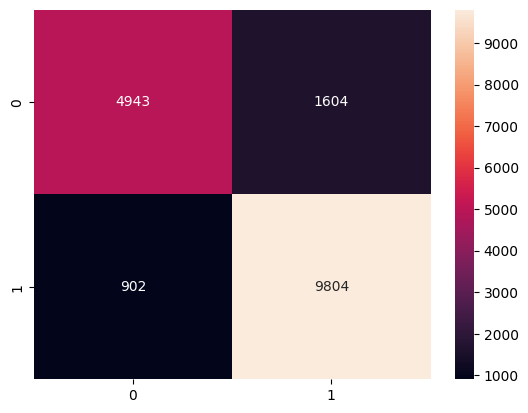

In [ ]:
from sklearn.metrics import confusion_matrix , f1_score , recall_score , precision_score ,roc_auc_score,roc_curve
from sklearn.metrics import log_loss
log_loss_score=log_loss(y_test, y_pred_proba)
print(f"recall score: {recall_score(y_test , y_pred)}")
print(f"precision score: {precision_score(y_test , y_pred)}")
print(f"f1score: {f1_score(y_test , y_pred)}")
print(f"auc score: {roc_auc_score(y_test,y_pred_proba)}")
print(f"confusion matrix: \n{confusion_matrix(y_test , y_pred)}")
print(f"log loss score ={log_loss_score}")

sns.heatmap(confusion_matrix(y_test , y_pred),annot=True ,fmt='d')


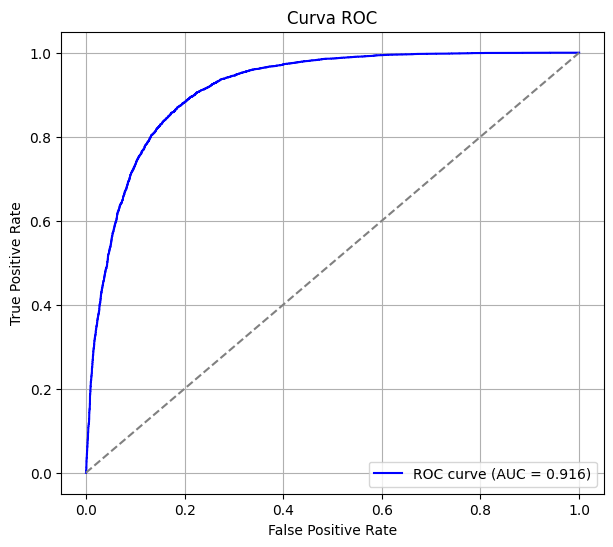

In [ ]:
import matplotlib.pyplot as plt
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

roc_auc = roc_auc_score(y_test, y_pred_proba)


plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # línea diagonal (azar)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


## MEDIDA A PARTIR DE LOG LOSS

In [ ]:
y_test

,target_binaria
14903,0
30335,1
52884,0
13872,0
6800,1
...,...
38717,0
21344,0
41455,1
53580,1


In [ ]:
y_test == 0

,target_binaria
14903,True
30335,False
52884,True
13872,True
6800,False
...,...
38717,True
21344,True
41455,False
53580,False


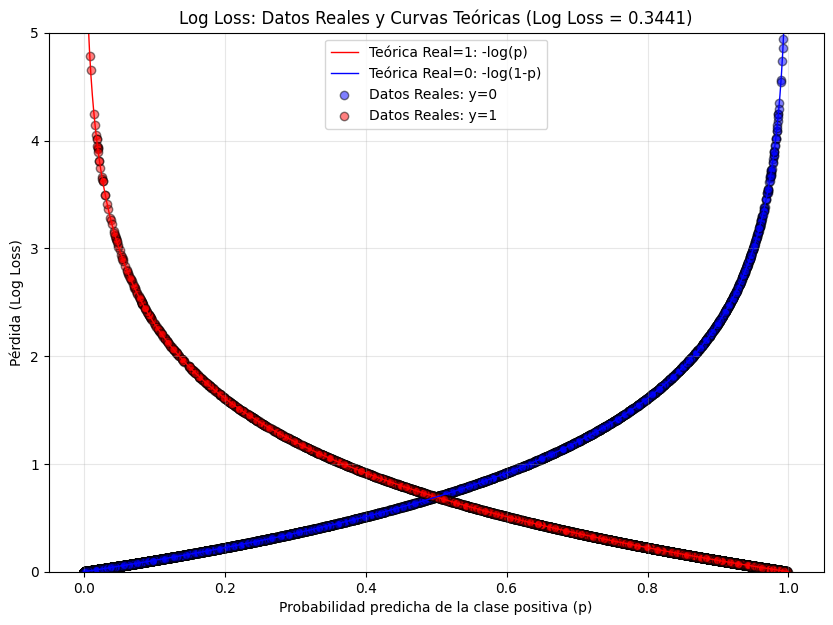

In [ ]:
import matplotlib.pyplot as plt

# curvas teóricas
# p: Rango de probabilidades de 0 a 1 (evitando los bordes para el logaritmo)
p = np.linspace(1e-6, 1-1e-6, 500)
loss_y1 = -np.log(p)       # Pérdida teórica cuando la CLASE REAL es 1
loss_y0 = -np.log(1 - p)   # Pérdida teórica cuando la CLASE REAL es 0

# Pérdidas Reales del Modelo
# Extraemos las probabilidades donde la clase real es 0 (p0) y donde es 1 (p1)
p0 = y_pred_proba[y_test["target_binaria"] == 0]
p1 = y_pred_proba[y_test["target_binaria"] == 1]

# pérdida REAL para cada grupo:
# Si la clase real es 0, la pérdida es -log(1 - p)
loss0 = -np.log(np.clip(1 - p0, 1e-15, 1))
# Si la clase real es 1, la pérdida es -log(p)
loss1 = -np.log(np.clip(p1, 1e-15, 1))

plt.figure(figsize=(10,7))

# Curvas suaves (teóricas)
plt.plot(p, loss_y1, 'r-', linewidth=1, label="Teórica Real=1: -log(p)")
plt.plot(p, loss_y0, 'b-', linewidth=1, label="Teórica Real=0: -log(1-p)")

# Puntos reales (Scatter Plot)
# Puntos azules: Casos donde la CLASE REAL es 0.
# La pérdida es alta si p (prob. de ser 1) es alto.
plt.scatter(p0, loss0, color="blue", alpha=0.5, edgecolor="k", label="Datos Reales: y=0")
# Puntos rojos: Casos donde la CLASE REAL es 1.
# La pérdida es alta si p (prob. de ser 1) es bajo.
plt.scatter(p1, loss1, color="red", alpha=0.5, edgecolor="k", label="Datos Reales: y=1")

plt.xlabel("Probabilidad predicha de la clase positiva (p)")
plt.ylabel("Pérdida (Log Loss)")
plt.title(f"Log Loss: Datos Reales y Curvas Teóricas (Log Loss = {log_loss_score:.4f})")
plt.legend()
plt.ylim(0, 5)
plt.grid(alpha=0.3)
plt.show()



## CURVA DE COMPLEJIDAD

In [ ]:
optimizacion.best_params_

{'solver': 'liblinear', 'penalty': 'l2', 'class_weight': None, 'C': 10}

In [ ]:
from sklearn.model_selection import cross_val_score,StratifiedKFold
model=LogisticRegression(solver='liblinear',penalty="l2" ,class_weight=None , C=0.01)
scores=cross_val_score(model , X_train , y_train , cv=3,scoring="roc_auc")
scores

c:\Users\chris\Data_science\Ms Data Mining UBA\2do_Cuatrimestre\AA\TPs\student-retention-ml\env_ml\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\chris\Data_science\Ms Data Mining UBA\2do_Cuatrimestre\AA\TPs\student-retention-ml\env_ml\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\chris\Data_science\Ms Data Mining UBA\2do_Cuatrimestre\AA\TPs\student-retention-ml\env_ml\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_

array([0.91173216, 0.91956819, 0.91735154])

In [ ]:
np.mean([1,2,6])

np.float64(3.0)

In [ ]:
y_train

,target_binaria
8559,1
34963,1
53046,1
41160,1
29742,1
...,...
8053,1
13351,0
41988,1
52611,1


In [ ]:
from sklearn.model_selection import cross_val_score,StratifiedKFold
from sklearn.metrics import roc_auc_score
c_values=np.linspace(0.001,100,25)
cv =StratifiedKFold(n_splits=3,random_state=42 ,shuffle=True)
scores_train=[]
scores_val=[]
for i,c in enumerate(c_values):
    print(i)

    fold_train=[]
    fold_val=[]
    for idx_train ,idx_val in cv.split(X_train,y_train):
        X_train_i = X_train.iloc[idx_train]
        y_train_i = y_train.iloc[idx_train].values.ravel()
        X_val_i = X_train.iloc[idx_val]
        y_val_i = y_train.iloc[idx_val].values.ravel()

        model=LogisticRegression(solver='liblinear',penalty="l2" ,class_weight=None , C=c, max_iter=1000)

        model.fit(X_train_i,y_train_i)

        y_pred_train_i = model.predict_proba(X_train_i)[:,1]
        y_pred_val_i = model.predict_proba(X_val_i)[:,1]

        train_score_i=roc_auc_score(y_train_i , y_pred_train_i)
        val_score_i=roc_auc_score(y_val_i,y_pred_val_i)

        fold_train.append(train_score_i)
        fold_val.append(val_score_i)
    score_train = float(np.mean(fold_train))
    score_val = float(np.mean(fold_val))

    scores_train.append(score_train)
    scores_val.append(score_val)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24


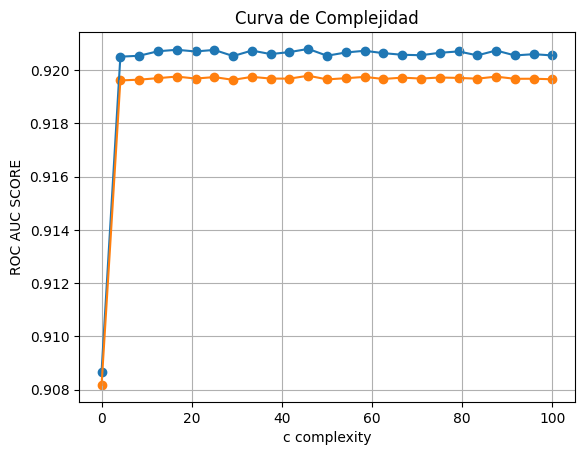

In [ ]:
plt.plot(c_values,scores_train)
plt.plot(c_values,scores_val)
plt.scatter(c_values,scores_train)
plt.scatter(c_values,scores_val)
plt.grid(True)
plt.ylabel("ROC AUC SCORE")
plt.xlabel("c complexity")
plt.title("Curva de Complejidad")
plt.show()

# feature imporance RL

                                                        coef  coef_std  \
ratio_aprobadas_inscrito_1sem_fe                   -0.735471 -7.329229   
Unidades_curriculares_2do_semestre_(aprobadas)      0.861024  1.566541   
Unidades_curriculares_1er_semestre_(aprobadas)      0.608504  1.035028   
Unidades_curriculares_2do_semestre_(inscrito)      -0.608343 -0.760578   
modo_aplicacion_label_Acceso General               -1.346883 -0.624725   
modo_aplicacion_label_Acceso por Normativa Espe... -1.304573 -0.523296   
Unidades_curriculares_1er_semestre_(inscrito)      -0.338604 -0.456031   
Pago_de_matrícula_al_día_transformed                2.277366  0.446101   
Poseedor_de_Beca_transformed                        0.805407  0.374236   
modo_aplicacion_label_Contingente Especial (Reg... -1.157076 -0.364592   
estado_civil_label_1 - Soltero                     -1.475916 -0.357920   
Nota_promedio_en_el_2do_semestre                    0.052901  0.337977   
Nota_promedio_en_el_1er_semestre      

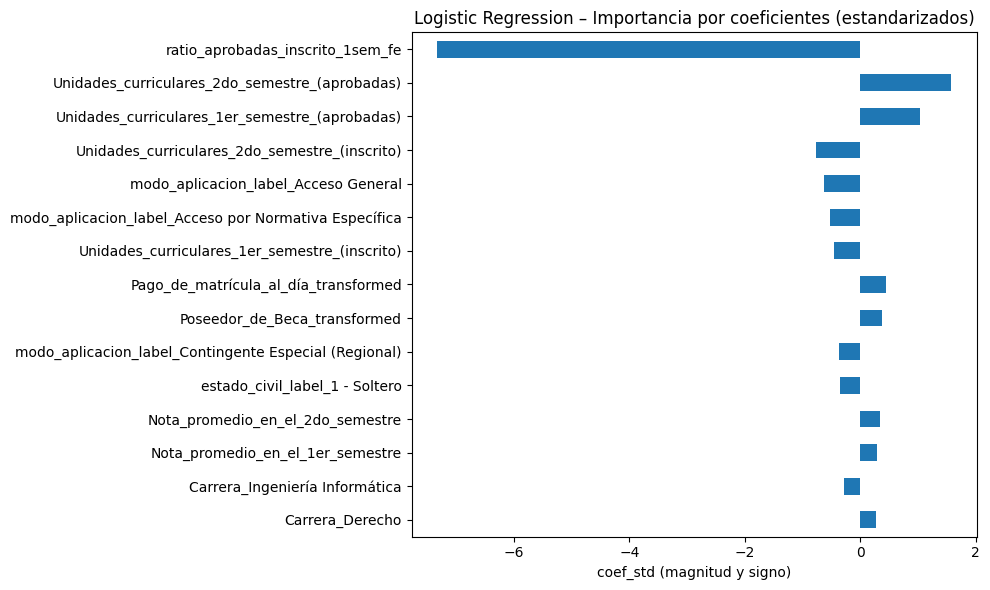

                                                    perm_importance_auc
Unidades_curriculares_2do_semestre_(aprobadas)                 0.146589
Unidades_curriculares_1er_semestre_(aprobadas)                 0.053884
modo_aplicacion_label_Acceso General                           0.022507
Unidades_curriculares_2do_semestre_(inscrito)                  0.019954
modo_aplicacion_label_Acceso por Normativa Espe...             0.012483
Unidades_curriculares_1er_semestre_(inscrito)                  0.008592
Pago_de_matrícula_al_día_transformed                           0.008263
Poseedor_de_Beca_transformed                                   0.007432
Nota_promedio_en_el_2do_semestre                               0.007343
modo_aplicacion_label_Contingente Especial (Reg...             0.006911
estado_civil_label_1 - Soltero                                 0.005651
Nota_promedio_en_el_1er_semestre                               0.005539
Cantidad_de_evaluaciones_en_el_2do_semestre_                   0

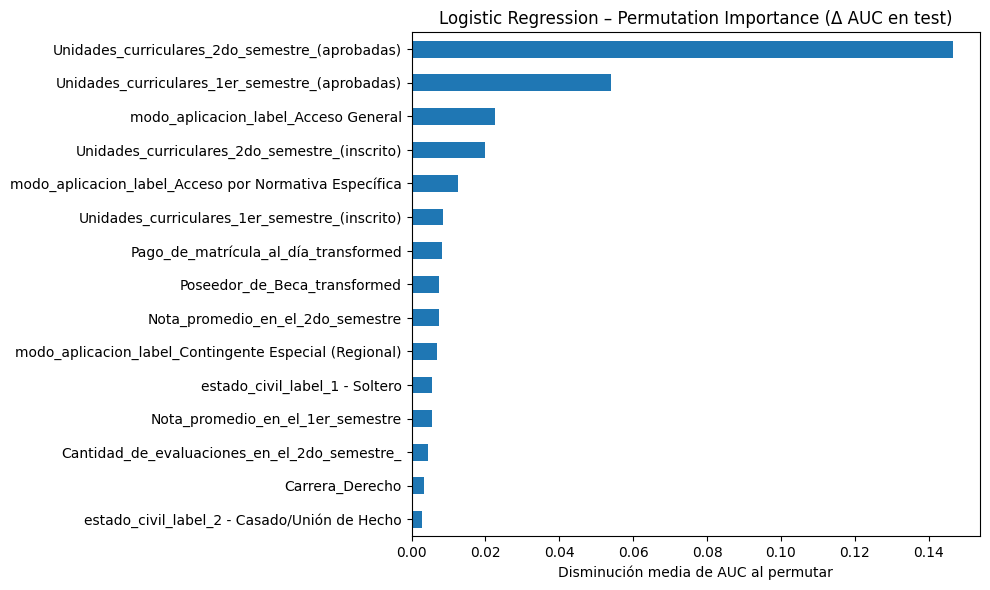

In [7]:
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# Entrenar el mejor modelo
logreg = LogisticRegression(
    solver="liblinear", penalty="l2", C=10, class_weight=None, max_iter=1000
)
logreg.fit(X_train, y_train.values.ravel())

# Importancia por coeficientes (estandarizados) + odds ratios
scaler = StandardScaler().fit(X_train)
coefs = pd.Series(logreg.coef_.ravel(), index=X_train.columns)
coefs_std = coefs * scaler.scale_     # ajusto por escala de cada feature
odds_ratio = np.exp(coefs)

feat_imp_coef = (
    pd.concat([coefs.rename("coef"),
               coefs_std.rename("coef_std"),
               odds_ratio.rename("odds_ratio")], axis=1)
      .assign(abs_coef_std=lambda d: d["coef_std"].abs())
      .sort_values("abs_coef_std", ascending=False)
)

topN = 15
print(feat_imp_coef.head(topN))

plt.figure(figsize=(10, 6))
feat_imp_coef.head(topN).sort_values("abs_coef_std")["coef_std"].plot(kind="barh")
plt.title("Logistic Regression – Importancia por coeficientes (estandarizados)")
plt.xlabel("coef_std (magnitud y signo)")
plt.tight_layout()
plt.show()

# Permutation Importance (sobre test)
from sklearn.metrics import roc_auc_score
r = permutation_importance(
    logreg, X_test, y_test.values.ravel(),
    n_repeats=20, scoring="roc_auc", random_state=42, n_jobs=-1
)
perm_df = (pd.Series(r.importances_mean, index=X_train.columns, name="perm_importance_auc")
             .sort_values(ascending=False)
             .to_frame())
print(perm_df.head(topN))

plt.figure(figsize=(10, 6))
perm_df.head(topN).sort_values("perm_importance_auc")["perm_importance_auc"].plot(kind="barh")
plt.title("Logistic Regression – Permutation Importance (Δ AUC en test)")
plt.xlabel("Disminución media de AUC al permutar")
plt.tight_layout()
plt.show()

# Guardados
feat_imp_coef.to_csv("logreg_feature_importance_coef.csv", index=True)
perm_df.to_csv("logreg_feature_importance_permutation.csv", index=True)



Top 20 features más importantes:
                                              feature  coefficient  \
9      Unidades_curriculares_2do_semestre_(aprobadas)     0.856297   
19               Pago_de_matrícula_al_día_transformed     0.785195   
45                                 Carrera_Psicología    -0.746254   
20                       Poseedor_de_Beca_transformed     0.705709   
43                     Carrera_Ingeniería Informática    -0.697301   
18                            Tiene_deuda_transformed    -0.642224   
36                                    Carrera_Derecho     0.642119   
7       Unidades_curriculares_2do_semestre_(inscrito)    -0.577685   
27                     estado_civil_label_1 - Soltero    -0.540432   
5      Unidades_curriculares_1er_semestre_(aprobadas)     0.536302   
16             Asistencia_diurna/nocturna_transformed    -0.468019   
14                             sexo_label_transformed    -0.363495   
35                                  Carrera_Agronomía   

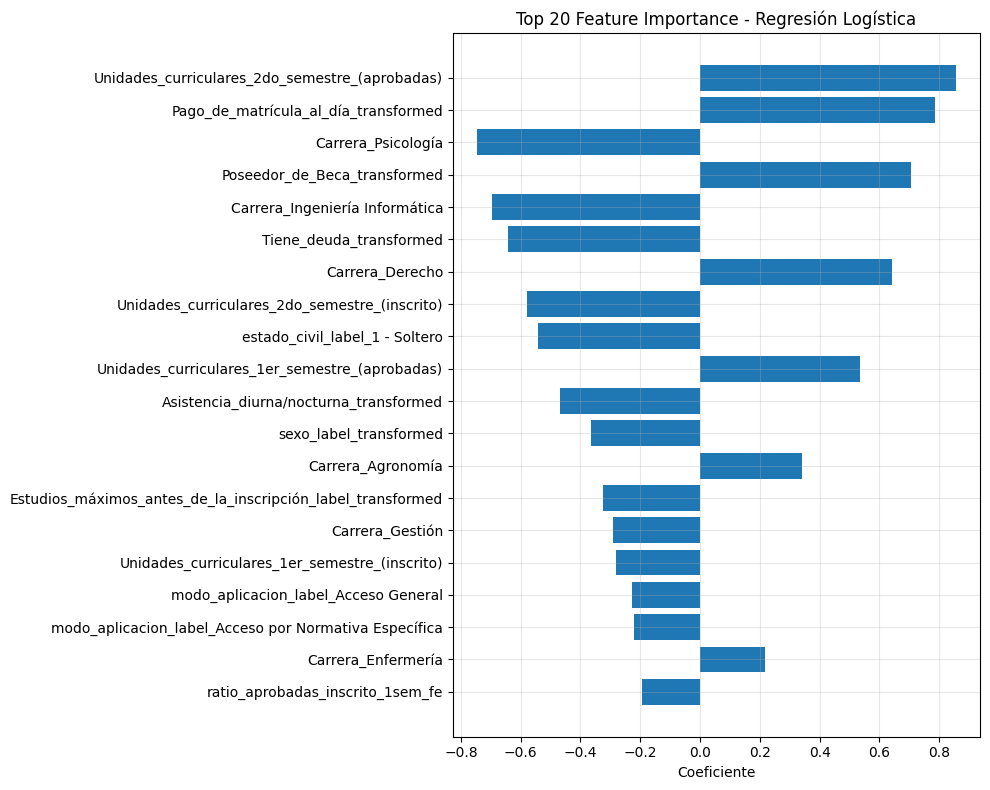


Resultados guardados en 'feature_importance.csv'


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression


# Entrenar modelo con los mejores hiperparámetros
model = LogisticRegression(solver='liblinear', penalty='l2', class_weight=None, C=0.01, max_iter=1000)
model.fit(X_train, y_train.values.ravel())

# Obtener coeficientes
coef = model.coef_[0]
features = X_train.columns

# Crear DataFrame con importancias
feature_importance = pd.DataFrame({
    'feature': features,
    'coefficient': coef,
    'abs_coefficient': np.abs(coef)
}).sort_values('abs_coefficient', ascending=False)

print("\nTop 20 features más importantes:")
print(feature_importance.head(20))

# Visualizar top 20
plt.figure(figsize=(10, 8))
top_20 = feature_importance.head(20)
plt.barh(range(len(top_20)), top_20['coefficient'])
plt.yticks(range(len(top_20)), top_20['feature'])
plt.xlabel('Coeficiente')
plt.title('Top 20 Feature Importance - Regresión Logística')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Guardar resultados
feature_importance.to_csv('feature_importance.csv', index=False)
print("\nResultados guardados en 'feature_importance.csv'")